# Manipulación y visualización de datos

En este taller estudiarás los conceptos mostrados en el tutorial de Introducción a librerías de manipulación de datos, ahora con un nuevo conjunto de datos. Específicamente, realizarás los siguientes pasos:

1. Cargar un conjunto de datos en formato .csv.
2. Analizar los datos y las variables que los conforman.
3. Consultar y manipular el conjunto de datos mediante localización por etiquetas y por índices.
4. Crear gráficas sencillas con Matplotlib y Seaborn.

El conjunto de datos a utilizar es un repositorio de música. Este conjunto representa canciones mediante su popularidad, bailabilidad, volumen, acústica, entre otras propiedades cuantificables.

Primero vamos a importar las librerías necesarias:

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import numpy as np

from importlib.metadata import version

Luego, revisamos la versiones de las librerías. Las librerías se actualizan frecuentemente y es útil saber esta información al momento de consultar documentación sobre las librerías. Además, facilita ejecutar este taller en otros entornos como un computador personal o Google Colab.

In [5]:
print(f"Versión de Pandas: {version('pandas')}")
print(f"Versión de Seaborn: {version('seaborn')}")
print(f"Versión de Matplotlib: {version('matplotlib')}")
print(f"Versión de Numpy: {version('numpy')}")

Versión de Pandas: 2.2.2
Versión de Seaborn: 0.13.2
Versión de Matplotlib: 3.10.5
Versión de Numpy: 1.26.4


## 1. Carga de datos

Iniciaremos con la importación de nuestro conjunto de datos.

### Ejercicio 1.1.

Utiliza Pandas para importar el archivo que contiene el conjunto de datos de canciones.

* La ruta del archivo .csv es: `./data/song_data.csv`, y ya se encuentra en el entorno de Coursera, solo debes importarlo.
* La variable resultante debe tener el nombre `data`.

Recuerda que usarás esta variable para todas las consultas sobre los datos.

In [6]:
ruta = './data/song_data.csv'
# Escribe tu código aquí
data = pd.read_csv('./data/song_data.csv')

Para este y los siguientes ejercicios encontrarás celdas, como la que se muestra a continuación, con pruebas unitarias para evaluar tu respuesta. Estas pruebas verificarán que tu respuesta tenga las dimensiones correctas y el tipo de dato correcto según la pregunta. Si todas las pruebas son exitosas, se ejecutará la línea con la función `print()` y el mensaje que indica que tu respuesta tiene el formato esperado.

In [7]:
#---------- Celda de Pruebas ----------
# La variable "data" existe
# El resultado es un DataFrame
# El resultado tiene las dimensiones correctas
#--------------------------------------

# Se verifica que la variable está definida
assert data is not None, "Asegúrate de definir la variable data."
assert ruta is not None, "Asegúrate de definir la variable con la ruta al archivo."

# Se verifica que sea un DataFrame
assert isinstance(data, pd.DataFrame), "El resultado es un DataFrame."

# Se evalúan las dimensiones de la variable data
assert data.shape == (18835,15), "¿Verificaste que la ruta del archivo CSV y el nombre de la variable son correctos?"
print("¡Los datos tienen las dimensiones correctas!")

¡Los datos tienen las dimensiones correctas!


Para tener una idea del contenido de los datos, vamos a visualizar nuestro DataFrame utilizando `data.head()`:

In [8]:
data.head()

,song_name,song_popularity,song_duration_ms,acousticness,danceability,energy,instrumentalness,key,liveness,loudness,audio_mode,speechiness,tempo,time_signature,audio_valence
0,Boulevard of Broken Dreams,73,262333,0.005520,0.496,0.682,0.000029,8,0.0589,-4.095,1,0.0294,167.060,4,0.474
1,In The End,66,216933,0.010300,0.542,0.853,0.000000,3,0.1080,-6.407,0,0.0498,105.256,4,0.370
2,Seven Nation Army,76,231733,0.008170,0.737,0.463,0.447000,0,0.2550,-7.828,1,0.0792,123.881,4,0.324
3,By The Way,74,216933,0.026400,0.451,0.970,0.003550,0,0.1020,-4.938,1,0.1070,122.444,4,0.198
4,How You Remind Me,56,223826,0.000954,0.447,0.766,0.000000,10,0.1130,-5.065,1,0.0313,172.011,4,0.574


## 2. Descripción de los datos

Como vimos anteriormente, también podemos utilizar Pandas para describir los datos utilizando una función.

### Ejercicio 2.1.

En la siguiente celda, obtén una descripción de los datos utilizando Pandas. Utiliza el resultado para responder a las preguntas que se muestran más adelante.
* Define una variable con el nombre `p21` y asígnale el valor correspondiente.
* Encontrarás una línea solo con el nombre de la variable. Esta línea se usa para que puedas visualizar tu respuesta, por lo que siempre debe ir al final y no la debes modificar.

In [9]:
# Escribe tu código aquí
p21 = data.describe()
p21

,song_popularity,song_duration_ms,acousticness,danceability,energy,instrumentalness,key,liveness,loudness,audio_mode,speechiness,tempo,time_signature,audio_valence
count,18835.000000,1.883500e+04,18835.000000,18835.000000,18835.000000,18835.000000,18835.000000,18835.000000,18835.000000,18835.000000,18835.000000,18835.000000,18835.000000,18835.000000
mean,52.991877,2.182116e+05,0.258539,0.633348,0.644995,0.078008,5.289196,0.179650,-7.447435,0.628139,0.102099,121.073154,3.959119,0.527967
std,21.905654,5.988754e+04,0.288719,0.156723,0.214101,0.221591,3.614595,0.143984,3.827831,0.483314,0.104378,28.714456,0.298533,0.244632
min,0.000000,1.200000e+04,0.000001,0.000000,0.001070,0.000000,0.000000,0.010900,-38.768000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,40.000000,1.843395e+05,0.024100,0.533000,0.510000,0.000000,2.000000,0.092900,-9.044000,0.000000,0.037800,98.368000,4.000000,0.335000
50%,56.000000,2.113060e+05,0.132000,0.645000,0.674000,0.000011,5.000000,0.122000,-6.555000,1.000000,0.055500,120.013000,4.000000,0.527000
75%,69.000000,2.428440e+05,0.424000,0.748000,0.815000,0.002570,8.000000,0.221000,-4.908000,1.000000,0.119000,139.931000,4.000000,0.725000
max,100.000000,1.799346e+06,0.996000,0.987000,0.999000,0.997000,11.000000,0.986000,1.585000,1.000000,0.941000,242.318000,5.000000,0.984000


In [10]:
#---------- Celda de Pruebas ----------
# La variable "p21" existe
# El resultado es un DataFrame
# El resultado tiene las dimensiones correctas
#--------------------------------------

# Se verifica que la variable está definida
assert p21 is not None, "Asegúrate de definir la variable correctamente."

# Se verifica que sea un DataFrame
assert isinstance(p21, pd.DataFrame), "El resultado es un DataFrame."

# Se evalúan las dimensiones de la respuesta 2.1
assert p21.shape == (8,14), "Utiliza una función de Pandas para obtener una descripción general de los datos."
print("¡Las dimensiones son correctas!")

¡Las dimensiones son correctas!


#### Pregunta 2.1.1.

¿Qué bailabilidad media tienen las canciones?

* La bailabilidad corresponde a la variable `danceability`.
* Para responder a la pregunta, define una variable con el nombre `p211` y asígnale el valor correspondiente. (**Ejemplo: `p211 = 1`**)
* Encontrarás una línea solo con el nombre de la variable. Esta línea se usa para que puedas visualizar tu respuesta, por lo que siempre debe ir al final y no la debes modificar.

In [11]:
# Escribe tu código aquí
p211 = 0.633348
p211

0.633348

In [12]:
#---------- Celda de Pruebas ----------
# La variable "p211" existe
# El resultado es un número de tipo "float"
# El resultado se encuentra en el rango [0,1]
#--------------------------------------

# Se verifica que la variable está definida
assert p211 is not None, "Asegúrate de definir la variable correctamente."

# Se evalúa el tipo de dato
assert type(p211) == float or type(p211) == np.float64, "Recuerda que tu respuesta debe ser un número."

# Se evalúa el rango de respuesta
assert (p211 >= 0 and p211 <= 1), "Verifica los límites de la variable que aparecen en el ejercicio 2.1."
print("¡El tipo y rango de la respuesta son correctos!")

¡El tipo y rango de la respuesta son correctos!


#### Pregunta 2.1.2.

¿Cuál es la puntuación máxima de popularidad?

* Para responder a la pregunta, define una variable con el nombre `p212` y asígnale el valor correspondiente. (**Ejemplo: `p212 = 10`**)
* Encontrarás una línea solo con el nombre de la variable. Esta línea se usa para que puedas visualizar tu respuesta, por lo que siempre debe ir al final y no la debes modificar.

In [13]:
# Escribe tu código aquí
p212 = 100
p212

100

In [14]:
#---------- Celda de Pruebas ----------
# La variable "p212" existe
# El resultado es un número entero
# El resultado está en el rango [0,100]
#--------------------------------------

# Se verifica que la variable está definida
assert p212 is not None, "Asegúrate de definir la variable correctamente."

# Se evalúa el tipo de dato
assert type(p212) == int or type(p212) == np.int64, "Recuerda que tu respuesta debe ser un número entero."

# Se evalúa el rango de respuesta
assert (p212 >= 0 and p212 <= 100), "Verifica los límites de la variable que aparecen en el ejercicio 2.1."
print("¡El tipo de dato y el rango de la respuesta son correctos!")

¡El tipo de dato y el rango de la respuesta son correctos!


#### Pregunta 2.1.3.

¿Cuál es el valor de energía mínima?

* Para responder a la pregunta, define una variable con el nombre `p213` y asígnale el valor correspondiente. (**Ejemplo: `p213 = 0.5`**)
* Encontrarás una línea solo con el nombre de la variable. Esta línea se usa para que puedas visualizar tu respuesta, por lo que siempre debe ir al final y no la debes modificar.

In [15]:
# Escribe tu código aquí
p213 = 0.001070
p213

0.00107

In [16]:
#---------- Celda de Pruebas ----------
# La variable "p213" existe
# El resultado es un número de tipo "float"
# El resultado está en el rango [0,1]
#--------------------------------------

# Se verifica que la variable está definida
assert p213 is not None, "Asegúrate de definir la variable correctamente."

# Se evalúa el tipo de dato
assert type(p213) == float or type(p213) == np.float64, "Recuerda que tu respuesta debe ser un número."

# Se evalúa el rango de respuesta
assert (p213 >= 0 and p213 <= 1), "Verifica los límites de la variable que aparecen en el ejercicio 2.1."
print("¡El tipo y rango de la respuesta son correctos!")

¡El tipo y rango de la respuesta son correctos!


### Ejercicio 2.2.

#### Pregunta 2.2.1.

Primero, utiliza la siguiente celda para obtener un conteo de la cantidad de apariciones de cada puntuación de popularidad.

* Define una variable con el nombre `p221` y asígnale la consulta correspondiente (`p221 = <<Consulta>>`).
* Encontrarás una línea solo con el nombre de la variable. Esta línea se usa para que puedas visualizar tu respuesta, por lo que siempre debe ir al final y no la debes modificar.

In [17]:
# Escribe tu código aquí
p221 = data['song_popularity'].value_counts()
p221

song_popularity
58     404
52     389
55     388
60     383
63     378
      ... 
98      47
97      36
93      32
99      16
100     12
Name: count, Length: 101, dtype: int64

In [18]:
#---------- Celda de Pruebas ----------
# La variable "p221" existe
# El resultado tiene las dimensiones correctas
#--------------------------------------

# Se verifica que la variable está definida
assert p221 is not None, "Asegúrate de definir la variable correctamente."

# Se verifican las dimensiones de la variable "p221"
assert p221.shape == (101,), "Pandas ofrece una función para el conteo de datos, que recibe como argumento una consulta sobre el DataFrame. Esta consulta tiene que usar la variable \'song_popularity\'"
print("¡La respuesta tiene las dimensiones correctas!")

¡La respuesta tiene las dimensiones correctas!


#### Pregunta 2.2.2.

Utiliza la información obtenida para responder: ¿Cuántas canciones tienen la máxima puntuación?

* Para responder a la pregunta, define una variable con el nombre `p222` y asígnale el valor correspondiente. (**Ejemplo: `p222 = 50`**)
* Encontrarás una línea solo con el nombre de la variable. Esta línea se usa para que puedas visualizar tu respuesta, por lo que siempre debe ir al final y no la debes modificar.

In [19]:
# Escribe tu código aquí
p222 = 58
p222

58

In [20]:
#---------- Celda de Pruebas ----------
# La variable "p22" existe
# El resultado es un número entero
# El resultado está en el rango [0,18835]
#--------------------------------------

# Se verifica que la variable está definida
assert p222 is not None, "Asegúrate de definir la variable correctamente."

# Se evalúa el tipo de dato
assert type(p222) == int or type(p222) == np.int64, "Recuerda que tu respuesta debe ser un número entero."

# Se evalúa el rango de respuesta
assert (p222 >= 0 and p222 <= 18835), "La respuesta debe ser menor o igual al total de datos."
print("¡La respuesta tiene el tipo y rango correcto!")

¡La respuesta tiene el tipo y rango correcto!


## 3. Consulta y modificación de datos

Después de visualizar y analizar los datos de forma general, realiza algunas consultas sobre ellos:

### Ejercicio 3.1.

Utiliza la localización por índices para obtener el dato con índice 300.

* Define una variable con el nombre `p31` y asígnale la consulta (`p31 = <<Consulta>>`). Esto permitirá que puedas acceder al resultado de la consulta en cualquier momento (simplemente colocando el nombre de la variable).
* Encontrarás una línea solo con el nombre de la variable. Esta línea se usa para que puedas visualizar tu respuesta, por lo que siempre debe ir al final y no la debes modificar.

In [21]:
# Escribe tu código aquí
p31 = data.iloc[300]
p31

song_name           Yesterday - Remastered 2009
song_popularity                              74
song_duration_ms                         125666
acousticness                              0.879
danceability                              0.332
energy                                    0.179
instrumentalness                            0.0
key                                           5
liveness                                 0.0886
loudness                                 -11.83
audio_mode                                    1
speechiness                              0.0326
tempo                                    96.529
time_signature                                4
audio_valence                             0.315
Name: 300, dtype: object

In [22]:
#---------- Celda de Pruebas ----------
# La variable "p31" existe
# El resultado es una Serie de Pandas
# El resultado tiene las dimensiones correctas
#--------------------------------------

# Se verifica que la variable está definida
assert p31 is not None, "Asegúrate de definir la variable correctamente."

# Se verifica que sea una Serie
assert isinstance(p31, pd.Series), "El resultado es una Serie de Pandas, resultado de una consulta."

# Se verifican las dimensiones de la respuesta
assert p31.shape == (15,), "Recuerda utilizar 300 como argumento de tu consulta."
print("¡La respuesta tiene las dimensiones correctas!")

¡La respuesta tiene las dimensiones correctas!


### Ejercicio 3.2.

Obtén las canciones en el intervalo definido por los índices 400 y 500.

* Define una variable con el nombre `p32` y asígnale la consulta (`p32 = <<Consulta>>`).
* Encontrarás una línea solo con el nombre de la variable. Esta línea se usa para que puedas visualizar tu respuesta, por lo que siempre debe ir al final y no la debes modificar.

In [23]:
# Escribe tu código aquí
p32 = data.iloc[400:500]
p32

,song_name,song_popularity,song_duration_ms,acousticness,danceability,energy,instrumentalness,key,liveness,loudness,audio_mode,speechiness,tempo,time_signature,audio_valence
400,And It Stoned Me,50,272160,0.35000,0.593,0.4680,0.000035,7,0.0919,-11.165,1,0.0285,75.798,4,0.597
401,Famous Blue Raincoat,58,310773,0.94800,0.474,0.0404,0.000263,9,0.1110,-22.208,0,0.0387,119.415,3,0.180
402,All Things Must Pass,59,226866,0.49400,0.508,0.5600,0.006110,9,0.1060,-8.244,1,0.0304,122.514,4,0.386
403,Stand By Me - Remastered,63,211666,0.29000,0.632,0.5560,0.021500,9,0.0779,-10.138,1,0.0288,104.996,4,0.633
404,"Baby, I Love Your Way",50,309760,0.61400,0.749,0.2460,0.000138,0,0.0967,-12.847,1,0.0383,132.153,4,0.308
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,China Grove,67,195306,0.31900,0.623,0.9100,0.000448,9,0.0810,-8.448,1,0.0384,145.624,4,0.745
496,Foreplay / Long Time,64,467640,0.00975,0.436,0.6570,0.007480,5,0.0931,-8.868,1,0.0541,118.693,4,0.210
497,Come Sail Away,59,365000,0.16000,0.287,0.5620,0.000000,0,0.1030,-7.549,1,0.0304,147.622,4,0.126
498,Give A Little Bit,72,248173,0.06940,0.531,0.8180,0.009600,2,0.2630,-5.358,1,0.0452,90.767,4,0.471


In [24]:
#---------- Celda de Pruebas ----------
# La variable "p32" existe
# El resultado es un DataFrame
# El resultado tiene las dimensiones correctas
#--------------------------------------

# Se verifica que la variable está definida
assert p32 is not None, "Asegúrate de definir la variable correctamente."

# Se verifica que sea un DataFrame
assert isinstance(p32, pd.DataFrame), "El resultado es un DataFrame con 100 filas."

# Se evalúan las dimensiones de la respuesta
assert p32.shape == (100, 15), "Recuerda usar el intervalo 400:500."
print("¡La respuesta es un DataFrame con las dimensiones correctas!")

¡La respuesta es un DataFrame con las dimensiones correctas!


### Ejercicio 3.3.

Utiliza la localización por etiquetas para obtener la duración de la canción con índice 1000.

* Define una variable con el nombre `p33` y asígnale la consulta (`p33 = <<Consulta>>`). El resultado de esta consulta debe ser un número.
* Encontrarás una línea solo con el nombre de la variable. Esta línea se usa para que puedas visualizar tu respuesta, por lo que siempre debe ir al final y no la debes modificar.

In [25]:
# Escribe tu código aquí
p33 = data.loc[1000,'song_duration_ms']
p33

300773

In [26]:
#---------- Celda de Pruebas ----------
# La variable "p33" existe
# El resultado es un número entero
# El resultado está en el rango [0,1799346]
#--------------------------------------

# Se verifica que la variable está definida
assert p33 is not None, "Asegúrate de definir la variable correctamente."

# Se evalúa el tipo de dato
assert type(p33) == np.int64 or type(p33) == int, "En este caso tienes que localizar una celda del DataFrame. Es decir, tienes que consultar una fila (índice) y una columna (variable)."

# Se evalúa el rango de respuesta
assert (p33 >= 0 and p33 <= 1799346), "Verifica los límites de la variable \'song_duration_ms\' que aparecen en el ejercicio 2.1."
print("¡La respuesta tiene el rango correcto!")

¡La respuesta tiene el rango correcto!


### Ejercicio 3.4.

Filtra el DataFrame para obtener todas las canciones con popularidad mayor a 95.

* Define una variable con el nombre `p34` y asígnale la consulta (`p34 = <<Consulta>>`). En este caso, `p34` es un nuevo DataFrame.
* Encontrarás una línea solo con el nombre de la variable. Esta línea se usa para que puedas visualizar tu respuesta, por lo que siempre debe ir al final y no la debes modificar.

In [27]:
# Escribe tu código aquí
p34 = data.loc[data.loc[:,'song_popularity'] > 95]
p34

,song_name,song_popularity,song_duration_ms,acousticness,danceability,energy,instrumentalness,key,liveness,loudness,audio_mode,speechiness,tempo,time_signature,audio_valence
61,"Taki Taki (with Selena Gomez, Ozuna & Cardi B)",98,212500,0.15300,0.841,0.798,0.000003,1,0.0618,-4.206,0,0.2290,95.948,4,0.591
1229,I Love It (& Lil Pump),99,127946,0.01140,0.901,0.522,0.000000,2,0.2590,-8.304,1,0.3300,104.053,4,0.329
1230,Falling Down,97,196400,0.01750,0.669,0.574,0.002940,4,0.1460,-6.442,0,0.0286,120.013,4,0.273
1250,SICKO MODE,97,312820,0.00513,0.834,0.730,0.000000,8,0.1240,-3.714,1,0.2220,155.008,4,0.446
1251,Lucky You (feat. Joyner Lucas),96,244679,0.06270,0.876,0.786,0.000000,10,0.1270,-4.884,0,0.3060,153.068,4,0.575
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17794,Eastside (with Halsey & Khalid),98,173799,0.55500,0.560,0.680,0.000000,6,0.1160,-7.648,0,0.3210,89.391,4,0.319
17798,Be Alright,96,196373,0.69700,0.553,0.586,0.000000,11,0.0813,-6.319,1,0.0362,126.684,4,0.443
17803,FEFE (feat. Nicki Minaj & Murda Beatz),96,179404,0.08800,0.931,0.387,0.000000,1,0.1360,-9.127,1,0.4120,125.978,4,0.376
17815,"Taki Taki (with Selena Gomez, Ozuna & Cardi B)",98,212500,0.15300,0.841,0.798,0.000003,1,0.0618,-4.206,0,0.2290,95.948,4,0.591


In [28]:
#---------- Celda de Pruebas ----------
# La variable "p34" existe
# El resultado es un DataFrame
# El resultado tiene las dimensiones correctas
#--------------------------------------

# Se verifica que la variable está definida
assert p34 is not None, "Asegúrate de definir la variable correctamente."

# Se verifica que sea un DataFrame
assert isinstance(p34, pd.DataFrame), "El resultado es un DataFrame con 164 filas."

# Se evalúan las dimensiones de la respuesta
assert p34.shape == (164, 15), "Utiliza doble localización por etiquetas para evaluar la condición y filtrar el DataFrame"
print("¡La respuesta es un DataFrame con las dimensiones correctas!")

¡La respuesta es un DataFrame con las dimensiones correctas!


## 4. Visualización de datos

Finalmente, vamos a utilizar tres tipos de gráficos para visualizar algunas características del conjunto de datos.

### Ejercicio 4.1.

Completa el siguiente código para generar una gráfica de distribución de popularidad. En el eje `x` deben estar los valores posibles de popularidad, y en el eje `y` debe estar la cantidad de apariciones de cada popularidad.

A continuación puedes observar cómo se debe ver la gráfica resultante:

![Gráfica E4.1](./img/41.png "Gráfica resultante para E4.1.")

**Nota:** `% matplotlib inline` es un llamado a una función que permite que las gráficas se muestren correctamente en Jupyter Notebooks. Si en algún momento no aparecen tus gráficas, puedes regresar a esta celda, ejecutarla nuevamente y volver al punto en el que estabas.

In [29]:
%matplotlib inline

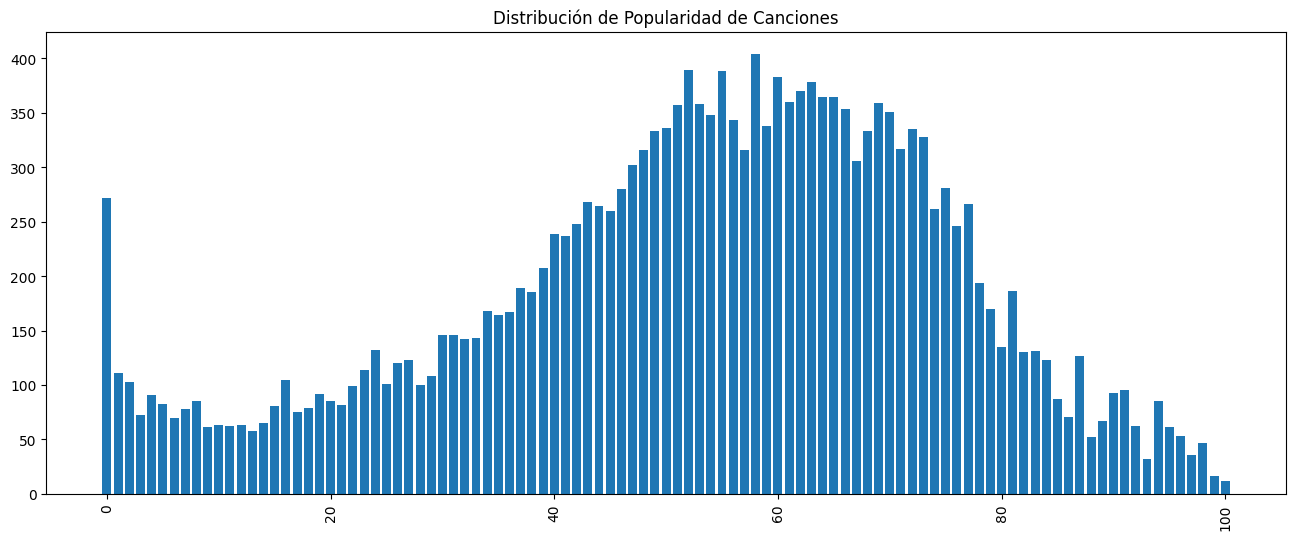

In [30]:
plt.figure(figsize=(16,6))

# Para resolver este punto, define dos variables x, y.
# Cada variable debe estar igualada a una consulta:
#   x = data[...].funcion()
#   y = data[...].funcion()
# Puedes usar localización por etiquetas o por índices, pero no es necesario.
# Igualmente, puedes usar la misma consulta para las dos variables, cambiando el atributo correspondiente
# Escribe tu código aquí
plot_data = data['song_popularity'].value_counts()
x = plot_data.index
y = plot_data.values

plt.bar(x,y)
plt.title('Distribución de Popularidad de Canciones')
plt.xticks(rotation=90)

plt.show()

In [31]:
#---------- Celda de Pruebas ----------
# La variables "x", "y" existen
# Las variables tienen las dimensiones correctas
#--------------------------------------

# Se verifica que las variables están definidas
assert x is not None, "Asegúrate de definir la variable correctamente."
assert y is not None, "Asegúrate de definir la variable correctamente."

# Se evalúan las dimensiones de la variable X
assert x.shape == (101,), "El eje x corresponde a los valores posibles de la popularidad. Encuentra una función que retorne los valores únicos de una variable."

# Se evalúan las dimensiones de la variable Y
assert y.shape == (101,), "El eje y corresponde a la cantidad de apariciones de un valor. Encuentra una función que cuente esas apariciones."
print("¡Las variables tienen las dimensiones correctas!")

¡Las variables tienen las dimensiones correctas!


### Ejercicio 4.2.

Completa el siguiente código, usando Seaborn, para generar un histograma de la energía de las canciones (variable `energy`).

La gráfica resultante se debe ver de la siguiente manera:

![Gráfica E4.2](./img/42.png "Gráfica resultante para E4.2.")

C:\Users\mjgar\AppData\Local\Temp\ipykernel_80500\543985061.py:13: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x, kde=True)


<Axes: xlabel='energy', ylabel='Density'>

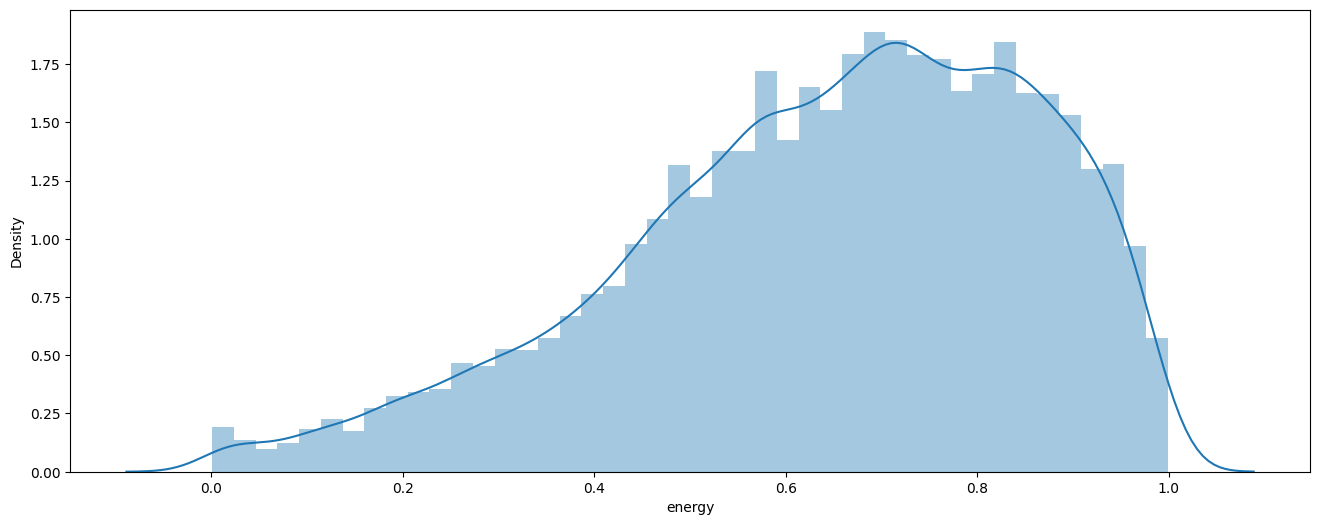

In [32]:
plt.figure(figsize=(16,6))
plt.tight_layout()

# Define una sola variable x.
# La variable debe estar igualada a una consulta:
#   x = data[...]

# Nota: en este punto estás reasignando (sobreescribiendo) la variable x del punto anterior.
#       En este caso no es importante, pero siempre debes tenerlo en cuenta.
# Escribe tu código aquí
x = data['energy']

sns.distplot(x, kde=True)

In [33]:
#---------- Celda de Pruebas ----------
# La variable "x" existe
# El resultado es una Serie de Pandas
# El resultado tiene las dimensiones correctas
#--------------------------------------

# Se verifica que la variable está definida
assert x is not None, "Asegúrate de definir la variable correctamente."

# Se verifica que sea una Serie
assert isinstance(x, pd.Series), "El resultado es una Serie de Pandas, resultado de una consulta."

# Se evalúan las dimensiones de la variable X
assert x.shape == (18835,), "Debes consultar la columna de la variable \'energy\'."
print("¡Las dimensiones de X son correctas!")

¡Las dimensiones de X son correctas!


### Ejercicio 4.3.

Completa el siguiente código para visualizar la relación entre energía (variable `energy`) y volumen (variable `loudness`). 
* Este gráfico debe tener los valores de energía en el eje `x`, y los valores de volumen en el eje `y`. 
* La forma de las marcas utilizadas debe ser de estrella.

El resultado de este ejercicio debe ser como se muestra a continuación:

![Gráfica E4.3](./img/43.png "Gráfica resultante para E4.3.")

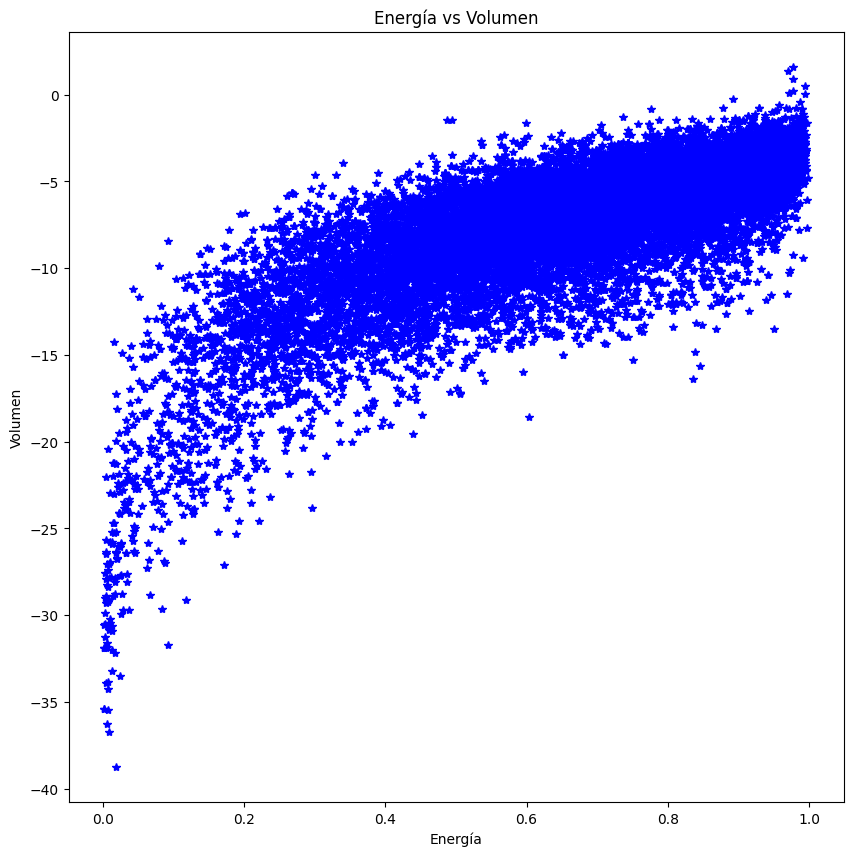

In [34]:
plt.figure(figsize=(10,10))

# Para resolver este punto, define dos variables x, y.
# Cada variable debe estar igualada a una consulta:
#   x = data[...]
#   y = data[...]

# Además, define una variable 'forma'.
# Esta variable debe estar igualada a un String.
# Por ejemplo, para que los marcadores tengan forma de punto:
# forma = '.'

# Escribe tu código aquí
x = data['energy']
y = data['loudness']

forma = '*'

plt.plot(x, y, forma, color = 'blue')
plt.title('Energía vs Volumen')
plt.xlabel('Energía')
plt.ylabel('Volumen')
plt.show()

In [35]:
#---------- Celda de Pruebas ----------
# El resultado tiene tres variables que existen
# Las variables "x", "y" tienen dimensiones correctas
# La variable "forma" es un String
#--------------------------------------

# Se verifica que las variables están definidas
assert x is not None, "Asegúrate de definir la variable correctamente."
assert y is not None, "Asegúrate de definir la variable correctamente."
assert forma is not None, "Asegúrate de definir la variable correctamente."

# Se evalúan las dimensiones de la variable X
assert x.shape == (18835,), "El eje x corresponde a la variable \'energy\'. Puedes usar loc, iloc, o consultar directamente."

# Se evalúan las dimensiones de la variable Y
assert y.shape == (18835,), "El eje y corresponde a la variable \'loudness\'. Puedes usar loc, iloc, o consultar directamente."

# Se evalúa el tipo de la variable forma
assert type(forma) == str, "Recuerda que este argumento describe la forma de los marcadores usando un caracter. Revisa la documentación de Matplotlib: https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.plot.html"
print("¡Las dimensiones de las variables y el tipo del argumento son correctas!")

¡Las dimensiones de las variables y el tipo del argumento son correctas!


## Cierre 

Al desarrollar los ejercicios de este taller, has practicado tus habilidades para cargar, analizar y consultar un conjunto de datos en Python. Además, lograste crear algunas visualizaciones básicas que te serán de ayuda en el análisis de tus datos para, en un futuro, crear modelos de aprendizaje automático a partir de ellos.

---

*Creado por: Nicolás Díaz*

*Última edición: Camilo Rozo*

*Revisado por: Haydemar Nuñez*

*Desarrollado por: María J. García-Bonilla*

*Versión de: Enero 20, 2025*

*Universidad de los Andes*  